In [1]:
import os
from typing import List, Optional
from operator import add

from pydantic import BaseModel, Field
from typing_extensions import Annotated

from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph

import wikipedia

c:\Users\dande\Lng-bot1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [63]:
os.environ["GROQ_API_KEY"] = "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"

In [64]:
def get_llm():
    return ChatGroq(
        model="openai/gpt-oss-120b",
        temperature=0
    )

In [48]:
from typing import Optional, List
from operator import add
from typing_extensions import Annotated
from langchain_core.messages import BaseMessage
from pydantic import BaseModel, Field

class AgentState(BaseModel):
    messages: Annotated[List[BaseMessage], add] = Field(default_factory=list)

    query: str
    route: Optional[str] = None

    wiki_result: Optional[str] = None
    vector_result: Optional[str] = None
    vector_sources: Optional[list] = None
    tool_result: Optional[str] = None

    intermediate_steps: Annotated[List[str], add] = Field(default_factory=list)

    final_answer: Optional[str] = None

In [5]:
def fetch_wikipedia(query: str) -> dict:
    try:
        page = wikipedia.page(query)
        summary = wikipedia.summary(query, sentences=3)

        return {
            "summary": summary,
            "page_title": page.title
        }

    except Exception as e:
        return {
            "summary": f"No result found: {str(e)}",
            "page_title": None
        }

In [6]:
def calculate(expression: str) -> str:
    try:
        return str(eval(expression))
    except Exception as e:
        return f"Error: {str(e)}"

In [7]:
def input_node(state: AgentState):
    print("[Input Node]")
    return {
        "messages": [HumanMessage(content=state.query)]
    }

In [67]:
def router_node(state):
    query = state.query.lower()

    # 🔥 RULE BASED (FAST + RELIABLE)
    if any(x in query for x in ["+", "-", "*", "/"]):
        return {"route": "math_tool"}

    if any(x in query for x in ["calculate", "solve"]):
        return {"route": "math_tool"}

    if any(x in query for x in ["notes", "pdf", "document"]):
        return {"route": "vector_db"}

    # 🔥 LLM fallback
    llm = get_llm()

    response = llm.invoke(f"""
You are a router.

Return ONLY one word from:
[wikipedia, vector_db, math_tool]

Query: {state.query}
""")

    route = response.content.strip().lower()

    print("ROUTE:", route)

    if "vector" in route:
        return {"route": "vector_db"}
    elif "math" in route:
        return {"route": "math_tool"}
    else:
        return {"route": "wikipedia"}

In [9]:
def wiki_node(state: AgentState):
    print("[Wikipedia Node]")

    result = fetch_wikipedia(state.query)

    return {
        "wiki_result": result["summary"],
        "messages": [AIMessage(content="Fetched from Wikipedia")]
    }

In [10]:
def tool_node(state: AgentState):
    print("[Tool Node]")

    result = calculate(state.query)

    return {
        "tool_result": result,
        "messages": [AIMessage(content=f"Calculated: {result}")]
    }

In [49]:
from langchain_core.messages import AIMessage

def vector_node(state: AgentState):
    print("[Vector Node]")

    result = rag_with_sources(state.query)

    return {
        "vector_result": result["answer"],
        "vector_sources": result["sources"],
        "messages": [
            AIMessage(content="Fetched from Vector DB (RAG)")
        ],
        "intermediate_steps": ["Used Vector DB"]
    }

In [51]:
def combine_node(state: AgentState):
    print("[Combine Node]")

    llm = get_llm()

    prompt = f"""
Answer the question clearly.

Question:
{state.query}

Context:
Wikipedia: {state.wiki_result}
Vector DB: {state.vector_result}
Tool: {state.tool_result}

If sources exist, mention them briefly.
"""

    response = llm.invoke(prompt)

    return {
        "final_answer": response.content
    }

In [52]:
def route_decision(state: AgentState):
    return state.route

In [53]:
from langgraph.graph import StateGraph

def build_graph():
    builder = StateGraph(AgentState)

    builder.add_node("input", input_node)
    builder.add_node("router", router_node)
    builder.add_node("wiki", wiki_node)
    builder.add_node("vector", vector_node)
    builder.add_node("tool", tool_node)
    builder.add_node("combine", combine_node)

    builder.set_entry_point("input")

    builder.add_edge("input", "router")

    builder.add_conditional_edges(
        "router",
        route_decision,
        {
            "wikipedia": "wiki",
            "vector_db": "vector",
            "math_tool": "tool"
        }
    )

    builder.add_edge("wiki", "combine")
    builder.add_edge("vector", "combine")
    builder.add_edge("tool", "combine")

    return builder.compile()

In [55]:
graph = build_graph()

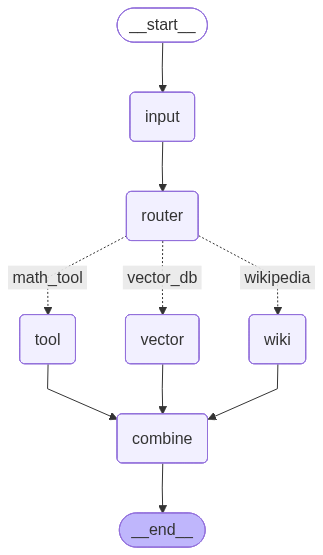

In [56]:
graph

In [54]:
graph = build_graph()

state = AgentState(query="Who is Albert Einstein? and 12 *(12 /3)")
result = graph.invoke(state)

print("\nFINAL ANSWER:\n")
print(result["final_answer"])

[Input Node]
[Router Node]
ROUTE: wikipedia
[Wikipedia Node]
[Combine Node]

FINAL ANSWER:

**Albert Einstein** was a German‑born theoretical physicist (1879–1955) who developed the theory of relativity, one of the two pillars of modern physics. His work revolutionized our understanding of space, time, and energy, and he is best known for the equation E = mc². He received the 1921 Nobel Prize in Physics for his explanation of the photoelectric effect. (Source: Wikipedia entry on Albert Einstein and the Einstein family.)

**Mathematical expression:**  
\(12 \times \left(\frac{12}{3}\right) = 12 \times 4 = 48\).

**Answer:** Albert Einstein was a pioneering physicist, and the value of 12 × (12 ÷ 3) is **48**.


In [21]:
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
#from langchain.community import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.retrievers import BM25Retriever
from langchain_core.documents import Document

In [22]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [36]:
loader = DirectoryLoader(
    "data",
    glob="**/*.pdf",
    loader_cls=PyPDFLoader
)

documents = loader.load()

print(f"Loaded {len(documents)} pages")

Loaded 1 pages


In [37]:
import re

def clean_text(text: str) -> str:
    # remove extra whitespace
    text = re.sub(r"\s+", " ", text)

    # remove weird unicode artifacts
    text = re.sub(r"[^\x00-\x7F]+", " ", text)

    # remove repeated dots
    text = re.sub(r"\.{2,}", ".", text)

    return text.strip()

In [38]:
from langchain_core.documents import Document

cleaned_documents = []

for doc in documents:
    cleaned_text = clean_text(doc.page_content)

    cleaned_documents.append(
        Document(
            page_content=cleaned_text,
            metadata=doc.metadata   # 🔥 keep metadata
        )
    )

print(f"Cleaned {len(cleaned_documents)} documents")

Cleaned 1 documents


In [39]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

chunks = splitter.split_documents(cleaned_documents)

print(f"Total chunks: {len(chunks)}")

Total chunks: 6


In [40]:
embedding = HuggingFaceEmbeddings()

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding,
    persist_directory="./chroma_db_1"
)

dense_retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

C:\Users\dande\AppData\Local\Temp\ipykernel_15076\202621943.py:1: LangChainDeprecationWarning: Default values for HuggingFaceEmbeddings.model_name were deprecated in LangChain 0.2.16 and will be removed in 0.4.0. Explicitly pass a model_name to the HuggingFaceEmbeddings constructor instead.
  embedding = HuggingFaceEmbeddings()
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8205.85it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [41]:
dense_retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

In [42]:
sparse_retriever = BM25Retriever.from_documents(chunks)
sparse_retriever.k = 3

In [43]:
def hybrid_retriever(query):
    dense_docs = dense_retriever.invoke(query)
    sparse_docs = sparse_retriever.invoke(query)

    docs = dense_docs + sparse_docs

    # remove duplicates
    seen = set()
    unique_docs = []

    for doc in docs:
        if doc.page_content not in seen:
            unique_docs.append(doc)
            seen.add(doc.page_content)

    return unique_docs[:5]

In [44]:
def format_docs(docs):
    return "\n\n".join([doc.page_content for doc in docs])

In [45]:
def rag_with_sources(query):
    docs = hybrid_retriever(query)

    context = format_docs(docs)

    llm = get_llm()

    response = llm.invoke(
        f"""
Answer the question using the context below.

Question:
{query}

Context:
{context}

Also mention sources if possible.
"""
    )

    sources = [
        {
            "file": doc.metadata.get("source"),
            "page": doc.metadata.get("page")
        }
        for doc in docs
    ]

    return {
        "answer": response.content,
        "sources": sources
    }

In [62]:
result = rag_with_sources("What is teh analysis source?")

print("\nANSWER:\n", result["answer"])
print("\nSOURCES:\n", result["sources"])


ANSWER:
 The analysis comes from the **sentiment‑analysis of the viewer feedback/comments on the YouTube video “End‑to‑End Multimodal LLMOPS Project Azure Deployment With Observability And Orchestration Engine.”**  

In other words, the positive/negative scores, overall “GREEN” sentiment, and the bullet‑point summary were generated by analysing the audience’s remarks (comments, likes/dislikes, etc.) associated with that video.

SOURCES:
 [{'file': 'data\\sentiment_report (1).pdf', 'page': 0}, {'file': 'data\\sentiment_report (1).pdf', 'page': 0}, {'file': 'data\\sentiment_report (1).pdf', 'page': 0}, {'file': 'data\\sentiment_report (1).pdf', 'page': 0}, {'file': 'data\\sentiment_report (1).pdf', 'page': 0}]


In [60]:
state = AgentState(query="Explain analysis from my notes")
result = graph.invoke(state)

print(result["final_answer"])
print(result["vector_sources"])

[Input Node]
[Router Node]
ROUTE: vector_db
[Vector Node]
[Combine Node]
**What the analysis of your notes is telling you**

Your viewers generally like the video (about 80 % positive sentiment), but a minority (≈20 %) raise concerns that affect how useful and accessible the content feels. The feedback falls into three main buckets: **how the video is delivered**, **technical clarity**, and **accessibility**. Below is a plain‑language breakdown of each part of the analysis and what it means for you.

---

### 1. Sentiment snapshot
| Sentiment | Share | Meaning |
|-----------|-------|---------|
| Positive  | ~80 % | Most people think the material is valuable and well‑executed. |
| Negative  | ~20 % | A smaller group is frustrated by format‑related issues (length, navigation, access) and a small visual mistake. |

---

### 2. Core pain‑points (why viewers are unhappy)

| Issue | Why it matters | Example from the notes |
|-------|----------------|------------------------|
| **Video length

In [61]:
state = AgentState(query="25 * 9")
result = graph.invoke(state)

print(result["final_answer"])

[Input Node]
[Router Node]
ROUTE: math_tool
[Tool Node]
[Combine Node]
25 × 9 = 225.
